# Phishing URL Detection: PhishTransformer

Character-level URL classification with CNN-only, Transformer-only, and hybrid CNN + Transformer models. Metrics in this notebook are produced only after the local datasets are loaded and training is run.

## 1. Introduction and Base Paper Technique

Base paper: Asiri et al., *PhishTransformer: A Novel Approach to Detect Phishing Attacks Using URL Collection and Transformer*, Electronics 13(1), 30 (2024), DOI 10.3390/electronics13010030. The paper collects URLs embedded in webpages, including hyperlinks and iframes, then combines convolutional features with Transformer encoders. This project adapts that local-plus-global idea to URL-string-only classification using PhishTank and Tranco text sources.

## 2. Dataset Loading, 3. Data Cleaning, and 4. Exploratory Data Analysis

The pipeline uses `verified_online.csv` from PhishTank for phishing URLs and `top-1m.csv` from Tranco for legitimate domains. Both sources provide URL/domain text suitable for the character-level model.

Skipping All.csv: it contains engineered features, not raw URL strings.
Project root: /workspaces/Phishing-URL-Detection
Phishing source: verified_online.csv; legitimate source: top-1m.csv
label
0    999996
1     68471
Name: count, dtype: int64


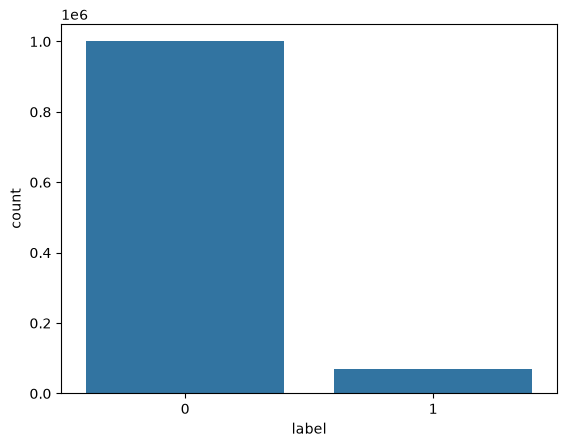

In [ ]:
import json, re, time
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses, metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
RANDOM_STATE, MAX_LEN, EMBED_DIM = 42, 256, 128

def find_project_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'Dataset').is_dir():
            return candidate
    raise FileNotFoundError('Could not find a Dataset directory from the notebook working directory.')

project_root = find_project_root()
root = project_root / 'Dataset'
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

def url_column(frame):
    raw_names = {'url', 'urls', 'raw_url', 'url_string', 'link', 'website', 'site'}
    candidates = [column for column in frame.columns if column.strip().lower() in raw_names]
    if not candidates:
        raise ValueError(f'No raw URL column found. Available columns: {list(frame.columns[:8])} ...')
    return candidates[0]

def clean_url(value):
    value = re.sub(r'\s+', '', str(value).strip().lower())
    value = re.sub(r'^https?://', '', value)
    value = re.sub(r'^www\.', '', value)
    return 'http://' + value

def load_phishing(path):
    frame = pd.read_csv(path, dtype=str, low_memory=False)
    column = url_column(frame)
    return pd.DataFrame({'url': frame[column], 'label': 1})

phishing = load_phishing(root / 'verified_online.csv')
top_path = root / 'tranco_K9Z7W.csv' if (root / 'tranco_K9Z7W.csv').exists() else root / 'top-1m.csv'
top = pd.read_csv(top_path, header=None, names=['rank', 'domain'], dtype=str)
data = pd.concat([
    phishing,
    pd.DataFrame({'url': top['domain'], 'label': 0}),
], ignore_index=True)
data['url'] = data['url'].dropna().map(clean_url)
data = data[data['url'].str.len() > len('http://')].drop_duplicates('url').reset_index(drop=True)
if data['label'].nunique() != 2:
    raise ValueError(f'Both classes are required after loading. Found labels: {data.label.unique().tolist()}')
print(f'Project root: {project_root}')
print(f'Phishing source: verified_online.csv; legitimate source: {top_path.name}')
print(data['label'].value_counts())
sns.countplot(data=data, x='label'); plt.show()

## 5. Character-level URL Encoding, 6. Data Balancing, and 7. Train/Test Split

In [26]:
MAX_SAMPLES_PER_CLASS = 1000
class_count = min(int(data.label.value_counts().min()), MAX_SAMPLES_PER_CLASS)
data = pd.concat([
    data[data.label == label].sample(class_count, random_state=RANDOM_STATE)
    for label in (0, 1)
]).sample(frac=1, random_state=RANDOM_STATE)
vocab = ['<PAD>', '<UNK>'] + sorted(set(''.join(data.url)) - {'<PAD>', '<UNK>'})
char2idx = {char: index for index, char in enumerate(vocab)}
def encode(url):
    values = [char2idx.get(char, 1) for char in url[:MAX_LEN]]
    return values + [0] * (MAX_LEN - len(values))
X = np.stack(data.url.map(encode)); y = data.label.to_numpy(dtype='int32')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=RANDOM_STATE)
print(f'Balanced samples: {len(data):,} ({class_count:,} per class)')
print(f'Train shape: {X_train.shape}; test shape: {X_test.shape}; vocabulary: {len(vocab)}')

Balanced samples: 2,000 (1,000 per class)
Train shape: (1600, 256); test shape: (400, 256); vocabulary: 59


## 8. CNN Model, 9. Transformer Model, and 10. Hybrid CNN + Transformer Model

Configuration: 256-character maximum, 128-dimensional embedding, CNN kernels 3 and 5, four attention heads, and two Transformer blocks.

In [27]:
class TransformerBlock(layers.Layer):
    def __init__(self):
        super().__init__(); self.att = layers.MultiHeadAttention(4, EMBED_DIM // 4); self.ffn = models.Sequential([layers.Dense(256, activation='relu'), layers.Dense(EMBED_DIM)]); self.n1 = layers.LayerNormalization(); self.n2 = layers.LayerNormalization()
    def call(self, x):
        a = self.att(x, x); x = self.n1(x + a); return self.n2(x + self.ffn(x))
def build_model(kind):
    inputs = layers.Input((MAX_LEN,), dtype='int32'); x = layers.Embedding(len(vocab), EMBED_DIM)(inputs)
    if kind in ('cnn', 'hybrid'): x = layers.Conv1D(128 if kind == 'cnn' else EMBED_DIM, 3, padding='same', activation='relu')(x); x = layers.Conv1D(128, 5, padding='same', activation='relu')(x) if kind == 'cnn' else x
    if kind in ('transformer', 'hybrid'):
        for _ in range(2): x = TransformerBlock()(x)
        x = layers.GlobalAveragePooling1D()(x)
    else: x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(.2)(layers.Dense(128, activation='relu')(x)); return models.Model(inputs, layers.Dense(1, activation='sigmoid')(x), name=kind)
model_map = {'CNN-only': build_model('cnn'), 'Transformer-only': build_model('transformer'), 'Hybrid': build_model('hybrid')}


## 11. Base Paper Technique Adaptation

The base paper's local-plus-global feature extraction is retained. Page-content URL collection is documented as a future extension because this project intentionally trains on the supplied URL datasets only.

## 12. Model Training

In [28]:
histories, train_times = {}, {}
for name, model in model_map.items():
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss=losses.BinaryCrossentropy(),
        metrics=[metrics.BinaryAccuracy(name='accuracy')],
    )
    start = time.time()
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=2,
        batch_size=8,
        callbacks=[
            callbacks.EarlyStopping(patience=1, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(patience=1),
        ],
        verbose=1,
    )
    histories[name] = history.history
    train_times[name] = time.time() - start
    print(f'{name} training time: {train_times[name]:.1f}s')

Epoch 1/2
 20/180 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5125 - loss: 0.6914

180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7424 - loss: 0.6550 - val_accuracy: 0.9688 - val_loss: 0.5661 - learning_rate: 1.0000e-04
Epoch 2/2
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9646 - loss: 0.3062 - val_accuracy: 0.9625 - val_loss: 0.1197 - learning_rate: 1.0000e-04
CNN-only training time: 20.5s
Epoch 1/2
180/180 ━━━━━━━━━━━━━━━━━━━━ 34s 175ms/step - accuracy: 0.7535 - loss: 0.4843 - val_accuracy: 0.8438 - val_loss: 0.3929 - learning_rate: 1.0000e-04
Epoch 2/2
180/180 ━━━━━━━━━━━━━━━━━━━━ 30s 169ms/step - accuracy: 0.8757 - loss: 0.2842 - val_accuracy: 0.8687 - val_loss: 0.3012 - learning_rate: 1.0000e-04
Transformer-only training time: 64.7s
Epoch 1/2
180/180 ━━━━━━━━━━━━━━━━━━━━ 36s 181ms/step - accuracy: 0.8424 - loss: 0.3491 - val_accuracy: 0.9688 - val_loss: 0.1156 - learning_rate: 1.0000e-04
Epoch 2/2
180/180 ━━━━━━━━━━━━━━━━━━━━ 38s 180ms/step - accuracy: 0.9757 - loss: 0.0846 - val_accuracy: 0.9625 - val_loss: 0.1260 - learning_rate: 1.0000e-0

## 13. Evaluation, 14. Accuracy / Precision / Recall / F1, 15. Confusion Matrix, and 16. ROC-AUC

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,CNN-only,0.9925,1.000000,0.985,0.992443,0.995600
1,Transformer-only,0.9175,0.971751,0.860,0.912467,0.976575
2,Hybrid,0.9925,1.000000,0.985,0.992443,0.995675


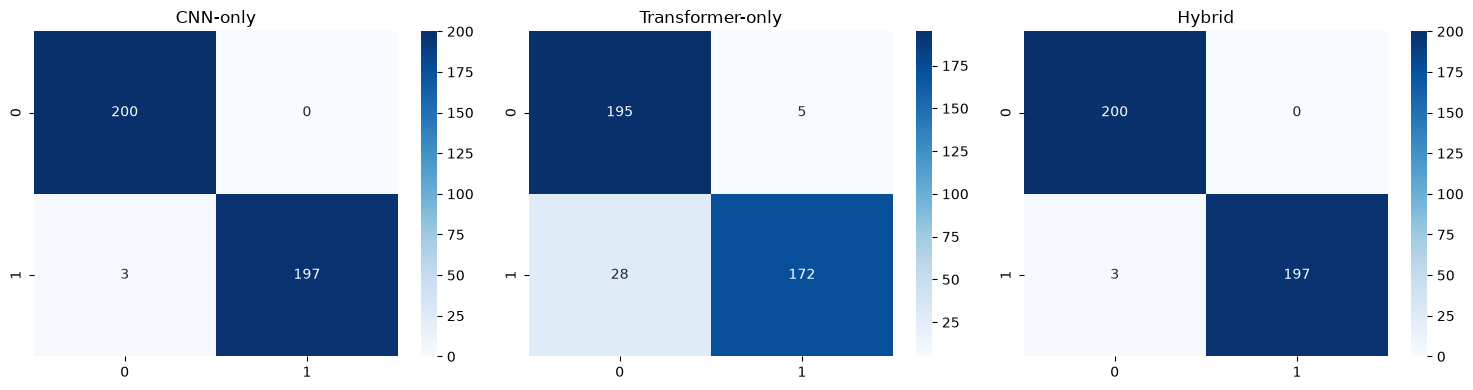

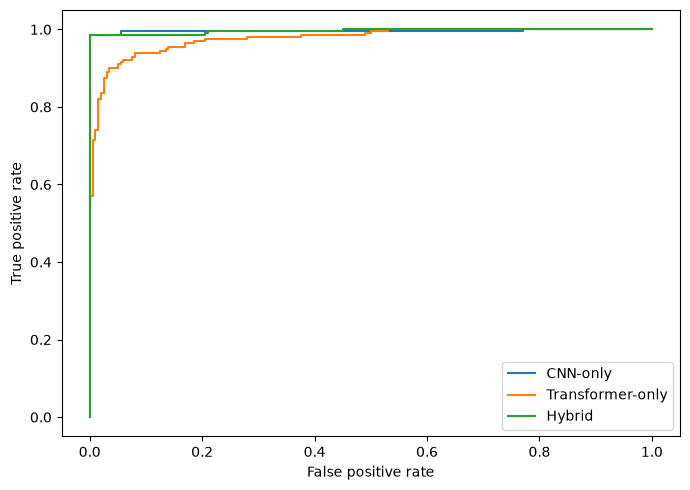

In [29]:
rows = []; predictions = {}
for name, model in model_map.items():
    probability = model.predict(X_test, verbose=0).ravel(); prediction = (probability >= .5).astype(int); predictions[name] = (probability, prediction)
    rows.append({'Model': name, 'Accuracy': accuracy_score(y_test, prediction), 'Precision': precision_score(y_test, prediction, zero_division=0), 'Recall': recall_score(y_test, prediction, zero_division=0), 'F1-Score': f1_score(y_test, prediction, zero_division=0), 'AUC-ROC': roc_auc_score(y_test, probability)})
results_df = pd.DataFrame(rows)
results_dir = project_root / 'results'; results_dir.mkdir(exist_ok=True)
results_df.to_csv(results_dir / 'metrics.csv', index=False); display(results_df)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, (name, (_, prediction)) in zip(axes, predictions.items()): sns.heatmap(confusion_matrix(y_test, prediction), annot=True, fmt='d', cmap='Blues', ax=axis); axis.set_title(name)
plt.tight_layout(); plt.savefig(results_dir / 'confusion_matrix.png', dpi=300)
plt.figure(figsize=(7, 5))
for name, (probability, _) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, probability); plt.plot(fpr, tpr, label=name)
plt.legend(); plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.tight_layout(); plt.savefig(results_dir / 'roc_curve.png', dpi=300); plt.show()

## 17. Model Comparison

The results below are this run's results. Do not copy the repository's historical 99.66% Transformer-only or 98.30% hybrid values unless this exact pipeline reproduces them.

In [31]:
best_name = max(
    results_df['Model'],
    key=lambda model_name: (
        results_df.loc[results_df['Model'] == model_name, 'F1-Score'].iloc[0],
        model_name == 'Hybrid',
    ),
)
models_dir = project_root / 'models'; models_dir.mkdir(exist_ok=True)
model_map[best_name].save(models_dir / 'final_phishing_model.keras')
(models_dir / 'vocab.json').write_text(json.dumps(char2idx), encoding='utf-8')
print(f'Selected model: {best_name}')
print(f'Model saved to: {models_dir / "final_phishing_model.keras"}')

Selected model: Hybrid
Model saved to: /workspaces/Phishing-URL-Detection/models/final_phishing_model.keras


## 18. Test Sample URLs, 19. Save Final Model, and 20. Prediction Function

In [32]:
def predict_url(url):
    probability = float(model_map[best_name].predict(np.asarray([encode(clean_url(url))]), verbose=0)[0][0]); label = 'PHISHING' if probability >= .5 else 'LEGITIMATE'; confidence = probability if label == 'PHISHING' else 1 - probability; return {'url': clean_url(url), 'prediction': label, 'confidence': confidence}
predict_url('https://example.com/login')


{'url': 'http://example.com/login',
 'prediction': 'PHISHING',
 'confidence': 0.9894450902938843}